# MM-ViT16 — Multimodal Fusion Ablation Study

**Purpose (Reviewer #2, Comment 3):** demonstrate that the performance of the
multimodal MM-ViT16 comes from *true cross-modal token-level fusion* of the SWE
image and the scalar stiffness (kPa) — not merely from the scalar value.

All arms are trained on the **same fixed split**, with **identical** preprocessing,
kPa normalization, augmentation, and training settings. The only thing that changes
between arms is the fusion mechanism. Each arm is trained over **multiple seeds**
and reported as **mean ± 95% CI** (Reviewer #2, Comment 4).

### Arms
| Arm | Description | Tests |
|-----|-------------|-------|
| `full` | Image patches + kPa token, fused by self-attention (the reported model) | reference |
| `image_only` | Same ViT, kPa removed, learnable CLS token instead | image's standalone value; **also = "stiffness-token-removed"** |
| `shuffled` | Full model, but kPa values permuted across samples (pairing broken) | **key control** — is fusion real or just the scalar? |
| `late_fusion` | Separate image-ViT and kPa-MLP, combined at the logits | early (token) vs late fusion |
| `stiffness_only` | Logistic regression on kPa alone (no image) | the scalar's own ceiling |

> Note: in this token-fusion architecture, "stiffness-token-removed" is structurally
> identical to `image_only` (removing the kPa token leaves a CLS-token ViT), so the two
> are merged into the single `image_only` arm. State this explicitly in the rebuttal.

The **stiffness-only** baseline runs as a 5th arm *inside this notebook* (logistic
regression on the rank-normalized kPa), under the **same splits, seeds, and test set**
as every ViT arm — so it is directly and fairly comparable, with matched CIs. (A richer
standalone diagnostic — decision boundary, per-class radar — also exists in
`stiffness_only_logistic_regression.py` for the supplement.)


## 0. Environment (RunPod)

Run once on a fresh pod. TensorFlow is assumed present from the base image;
this installs the lighter deps that base TF images sometimes lack.

In [7]:
# Uncomment on a fresh RunPod pod:
!pip install -q comet_ml scikit-learn scipy pandas openpyxl pillow


[notice] A new release of pip is available: 23.3.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


## 1. Configuration

Everything you might tune on RunPod is here. **Set the two paths first.**

In [2]:
# ─── Paths (EDIT THESE FOR RUNPOD) ──────────────────────────────────────────
IMAGES_DIR = "./Elastography_images"     # folder with response/ stable/ non-response/ subfolders
KPA_EXCEL  = "./clustering_all_v5.xlsx"   # Excel with 'name' + 'Elastic Modulus SWE (kPa)'

# ─── Output ─────────────────────────────────────────────────────────────────
# Mirrors the final project layout so results drop straight into
#   05_results/MM-ViT16/ablations/   and   03_models/MM-ViT16/ablations/
from pathlib import Path
OUTPUT_DIR = Path("./ablation_results")
DIR_TABLES   = OUTPUT_DIR / "tables"
DIR_PREDS    = OUTPUT_DIR / "predictions"
DIR_HIST     = OUTPUT_DIR / "histories"
DIR_FIG_PDF  = OUTPUT_DIR / "figures" / "pdf"
DIR_FIG_PNG  = OUTPUT_DIR / "figures" / "png"
DIR_CONFIG   = OUTPUT_DIR / "config"
DIR_SPLITS   = DIR_CONFIG / "splits"
DIR_MODELS   = OUTPUT_DIR / "models"      # download -> 03_models/MM-ViT16/ablations/
for d in (DIR_TABLES, DIR_PREDS, DIR_HIST, DIR_FIG_PDF, DIR_FIG_PNG,
          DIR_CONFIG, DIR_SPLITS, DIR_MODELS):
    d.mkdir(parents=True, exist_ok=True)
print("Output tree under", OUTPUT_DIR.resolve())

# ─── Ablation arms to run ───────────────────────────────────────────────────
# 'stiffness_only' is logistic regression on kPa alone (the reviewer's baseline),
# run under the SAME splits/seeds/normalization as the ViT arms for a fair compare.
ARMS = ["full", "image_only", "shuffled", "late_fusion", "stiffness_only"]

# ─── Seeds for confidence intervals ─────────────────────────────────────────
# First seed (42) reproduces the reported split. Train every arm on every seed.
SEEDS = [42, 1, 2, 3, 4]

# ─── Split fractions (current stratified-by-class split; seed 42 == run5) ────
# NOTE: swap in the animal-grouped split here once Valantis' animal IDs arrive
#       (Reviewer #2, Comment 1). The rest of the notebook is unaffected.
TEST_FRAC = 0.15
VAL_REL   = 0.15 / (1 - TEST_FRAC)

# ─── Image / model dimensions ───────────────────────────────────────────────
IMG_HEIGHT, IMG_WIDTH = 304, 400
PATCH_SIZE            = 16
CLASS_NAMES           = ["response", "stable", "non-response"]
NUM_CLASSES           = len(CLASS_NAMES)

# ─── Transformer hyperparameters (identical across arms) ────────────────────
TRANSFORMER_HEADS     = 4
TRANSFORMER_HEAD_SIZE = 32
TRANSFORMER_FF_DIM    = 128
TRANSFORMER_LAYERS    = 2
WEIGHT_DECAY          = 1e-4
DROPOUT_RATE          = 0.1
PROJECTION_DIM        = TRANSFORMER_HEAD_SIZE * TRANSFORMER_HEADS

# ─── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE = 32
EPOCHS     = 100
LR_INIT    = 1e-3

# ─── Data source: COMET artifact (same as the run5 notebook) ────────────────
# Images live in the Comet artifact 'elastography_images_merged' and unpack to
# ./Elastography_images/{response,stable,non-response}/. Set COMET_API_KEY in the
# pod environment. If IMAGES_DIR already exists locally, the download is skipped.
USE_COMET     = True
COMET_PROJECT = "multi_modal_development"
COMET_ARTIFACT = "elastography_images_merged"

# ─── kPa transform: RankNormalizer (percentile rank, cohort-robust) ─────────
KPA_TRANSFORM = "rank"

# ─── Augmentation ───────────────────────────────────────────────────────────
COLOR_AUGMENT = False   # geometric aug only, kept identical across arms

print("Arms :", ARMS)
print("Seeds:", SEEDS)
print(f"Total trainings: {len(ARMS) * len(SEEDS)}")

Output tree under /app/ablation_results
Arms : ['full', 'image_only', 'shuffled', 'late_fusion', 'stiffness_only']
Seeds: [42, 1, 2, 3, 4]
Total trainings: 25


## 2. Imports & GPU check

In [3]:
import os, json, joblib
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, optimizers, callbacks, Input, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils import shuffle as sk_shuffle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_auc_score, log_loss,
)
from sklearn.preprocessing import label_binarize

gpus = tf.config.list_physical_devices("GPU")
DEVICE = "/GPU:0" if gpus else "/CPU:0"
print("TensorFlow:", tf.__version__)
print("GPUs:", gpus)
print("Using device:", DEVICE)

2026-06-26 06:59:00.507538: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-26 06:59:00.550503: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-26 06:59:00.550535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-26 06:59:00.551837: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-26 06:59:00.558997: I tensorflow/core/platform/cpu_feature_guar

TensorFlow: 2.15.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Using device: /GPU:0


2026-06-26 06:59:02.636572: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-26 06:59:02.639268: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 3. Load data once (images + kPa + labels)

Loaded a single time; every arm and seed reuses these arrays.

**Images come from the Comet artifact** (same as the run5 notebook) — they are NOT
on the pod by default. The cell below downloads `elastography_images_merged` into
`./Elastography_images/` if that folder isn't already present. Requires
`COMET_API_KEY` in the environment. Upload `clustering_all_v5.xlsx` separately.

In [4]:
# ─── Comet experiment + image artifact (EXACT pattern from the ViT16 notebooks)
from comet_ml import Experiment

experiment = Experiment(
    api_key=os.getenv("COMET_API_KEY"),
    project_name=COMET_PROJECT,
    auto_histogram_weight_logging=True,
    auto_histogram_gradient_logging=True,
    auto_histogram_activation_logging=True,
)

# Retrieve the dataset artifact; download to ./ (creates ./Elastography_images)
logged_artifact = experiment.get_artifact("elastography_images_merged")
if not os.path.exists("./Elastography_images"):
    local_artifact = logged_artifact.download("./")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: keras, tensorflow, tensorboard, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/app' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/anabiosi-data/multi-modal-development/eab2f84048b14ecbbc8921d1629fd381

COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' download has been started asynchronously
COMET INFO: Still downloading 1598 file(s), remaining 722.63 MB/722.63 MB
COMET INFO: Still downloading 1408 file(s), remaining 628.97 MB/722.63 MB, Throughput 6.24 MB/s, ETA ~101s
COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' has been successfully downloaded


In [5]:
# ─── Load all images (EXACT pattern from the ViT16 notebooks) ───────────────
# Class names come from the artifact metadata (not hardcoded) — this is what
# guarantees flow_from_directory finds and maps the folders correctly.
class_names = logged_artifact.metadata["classes"]
assert class_names == CLASS_NAMES, (
    f"Artifact classes {class_names} != configured CLASS_NAMES {CLASS_NAMES}; "
    "align CLASS_NAMES in config to the artifact order.")

dataset = ImageDataGenerator().flow_from_directory(
    "./Elastography_images",
    batch_size=1579,                 # one big batch = load everything
    class_mode="sparse",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    shuffle=False,
    classes=class_names,
)
with tf.device(DEVICE):
    x_all, y_all = dataset.next()

basenames = [os.path.basename(p) for p in dataset.filenames]
print("Classes:", class_names)
print(f"Loaded {x_all.shape[0]} images, shape {x_all.shape}")
assert x_all.shape[0] > 0, "flow_from_directory found 0 images — check the artifact downloaded."

Found 1578 images belonging to 3 classes.


2026-06-26 06:59:36.210051: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-26 06:59:36.211101: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-26 06:59:36.232678: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29815 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:16:00.0, compute capability: 12.0
2026-06-26 06:59:36.234288: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 29815 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 5090, pci

Classes: ['response', 'stable', 'non-response']
Loaded 1578 images, shape (1578, 304, 400, 3)


In [8]:
# ─── Load kPa values and align to image order ───────────────────────────────
df = pd.read_excel(KPA_EXCEL)
df_small = df[["name", "Elastic Modulus SWE (kPa)"]].copy()
df_small.columns = ["filename", "elastic_modulus_kpa"]
# Normalize a Greek capital Tau sometimes present in filenames
df_small["filename"] = df_small["filename"].str.replace("\u03A4", "T", regex=False)

num_map = dict(zip(df_small["filename"], df_small["elastic_modulus_kpa"]))
missing = [b for b in basenames if b not in num_map]
assert not missing, f"{len(missing)} images missing kPa in Excel: {missing[:5]}"

X_num_all = np.array([num_map[b] for b in basenames], dtype=np.float32).reshape(-1, 1)
basenames_arr = np.array(basenames)

# Sanity checks
assert x_all.shape[0] == X_num_all.shape[0] == y_all.shape[0]
print("kPa range:", round(float(X_num_all.min()), 2), "-", round(float(X_num_all.max()), 2))
print("Class counts:", {CLASS_NAMES[i]: int((y_all == i).sum()) for i in range(NUM_CLASSES)})
print("\u2705 Images, kPa, and labels aligned.")

kPa range: 12.5 - 63.49
Class counts: {'response': 573, 'stable': 492, 'non-response': 513}
✅ Images, kPa, and labels aligned.


## 4. Helpers: split, kPa normalizer, data pipeline

Defined as functions so they can be re-run per seed with a clean state.

In [9]:
# ─── kPa rank-normalizer (fit on TRAIN only) ────────────────────────────────
class RankNormalizer:
    """Map kPa to percentile rank in (0,1) using the training distribution."""
    def __init__(self):
        self.train_sorted = None
    def fit(self, X_train):
        self.train_sorted = np.sort(np.asarray(X_train).flatten())
        return self
    def transform(self, X_new):
        arr = np.asarray(X_new).flatten()
        ranks = np.searchsorted(self.train_sorted, arr, side="right").astype(np.float64)
        n = len(self.train_sorted)
        return ((ranks - 0.5) / n).reshape(-1, 1).astype(np.float32)
    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [10]:
# ─── Stratified split, reproducible per seed ────────────────────────────────
# (Replace this function body with the animal-grouped split when available;
#  keep the same return signature.)
def make_split(seed):
    Xi, Xn, Y, idx, fn = sk_shuffle(
        x_all, X_num_all, y_all, np.arange(len(y_all)), basenames_arr,
        random_state=seed,
    )
    (Xi_tv, Xi_te, Xn_tv, Xn_te, Y_tv, Y_te, fn_tv, fn_te) = train_test_split(
        Xi, Xn, Y, fn, test_size=TEST_FRAC, random_state=seed,
        shuffle=True, stratify=Y,
    )
    (Xi_tr, Xi_va, Xn_tr, Xn_va, Y_tr, Y_va, fn_tr, fn_va) = train_test_split(
        Xi_tv, Xn_tv, Y_tv, fn_tv, test_size=VAL_REL, random_state=seed,
        shuffle=True, stratify=Y_tv,
    )
    return dict(
        Xi_tr=Xi_tr, Xn_tr=Xn_tr, Y_tr=Y_tr, fn_tr=fn_tr,
        Xi_va=Xi_va, Xn_va=Xn_va, Y_va=Y_va, fn_va=fn_va,
        Xi_te=Xi_te, Xn_te=Xn_te, Y_te=Y_te, fn_te=fn_te,
    )

In [11]:
# ─── tf.data pipeline ───────────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

def _preprocess(image, numeric, label):
    image   = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image   = tf.cast(image, tf.float32) / 255.0
    image   = tf.clip_by_value(image, 0.0, 1.0)
    numeric = tf.cast(numeric, tf.float32)
    label   = tf.cast(label, tf.int64)
    return (image, numeric), label

_data_augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.05),
], name="data_augmentation")

def _augment(inputs, label):
    image, numeric = inputs
    image = _data_augment(image)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return (image, numeric), label

def make_dataset(images, numerics, labels, seed, shuffle=False, augment=False, cache=False):
    with tf.device("/CPU:0"):
        ds = tf.data.Dataset.from_tensor_slices((images, numerics, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(images), seed=seed, reshuffle_each_iteration=True)
    ds = ds.map(_preprocess, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
    if cache:
        ds = ds.cache()
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

## 5. Model definitions

Custom layers `TokenSlice` / `CLSToken` (robust to TF reload). One `build_model(arm)`
function returns the architecture for each arm. The transformer encoder and every
hyperparameter are shared — only the fusion path changes.

In [12]:
# ─── Custom layers ──────────────────────────────────────────────────────────
class TokenSlice(layers.Layer):
    """Pick token at `index` from (batch, seq, dim)."""
    def __init__(self, index=0, **kw):
        super().__init__(**kw); self.index = index
    def call(self, x):
        return x[:, self.index, :]
    def get_config(self):
        return {**super().get_config(), "index": self.index}

class CLSToken(layers.Layer):
    """Learnable [CLS] token prepended to a patch sequence (image-only arm)."""
    def __init__(self, dim, **kw):
        super().__init__(**kw); self.dim = dim
    def build(self, input_shape):
        self.cls = self.add_weight(name="cls", shape=(1, 1, self.dim),
                                   initializer="random_normal", trainable=True)
    def call(self, x):
        batch = tf.shape(x)[0]
        return tf.concat([tf.tile(self.cls, [batch, 1, 1]), x], axis=1)
    def get_config(self):
        return {**super().get_config(), "dim": self.dim}

CUSTOM_OBJECTS = {"TokenSlice": TokenSlice, "CLSToken": CLSToken}

In [13]:
# ─── Shared transformer encoder ─────────────────────────────────────────────
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout_rate=0.1):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads,
                                  dropout=dropout_rate)(x, x)
    x = layers.Dropout(dropout_rate)(x)
    res = layers.Add()([inputs, x])
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return layers.Add()([res, x])


def _patch_tokens(image_input):
    """Image -> (batch, num_patches, projection_dim)."""
    x = layers.Conv2D(
        filters=PROJECTION_DIM, kernel_size=(PATCH_SIZE, PATCH_SIZE),
        strides=(PATCH_SIZE, PATCH_SIZE), padding="valid",
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name="patch_proj",
    )(image_input)
    num_patches = x.shape[1] * x.shape[2]
    return layers.Reshape((num_patches, PROJECTION_DIM), name="patch_tokens")(x), num_patches


def _transformer_stack(tokens, seq_len):
    pos_emb = layers.Embedding(input_dim=seq_len, output_dim=PROJECTION_DIM,
                               name="pos_embedding")
    positions = tf.range(start=0, limit=seq_len, delta=1)[tf.newaxis, :]
    x = layers.Add(name="add_pos")([tokens, pos_emb(positions)])
    for _ in range(TRANSFORMER_LAYERS):
        x = transformer_encoder(x, TRANSFORMER_HEAD_SIZE, TRANSFORMER_HEADS,
                                TRANSFORMER_FF_DIM, DROPOUT_RATE)
    return x


def _head(cls):
    cls = layers.LayerNormalization(epsilon=1e-6, name="cls_norm")(cls)
    h = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                     name="cls_embedding")(cls)
    h = layers.Dropout(DROPOUT_RATE, name="cls_dropout")(h)
    return layers.Dense(NUM_CLASSES, activation="softmax",
                        kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                        name="predictions")(h)

In [14]:
def build_model(arm):
    """Return the Keras model for a given ablation arm.

    All arms accept the SAME (image, numeric) input signature so the data
    pipeline is shared. Arms that ignore kPa simply don't connect num_input.
    """
    image_input = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="image_input")
    num_input   = Input(shape=(1,), name="num_input")
    patch_tokens, num_patches = _patch_tokens(image_input)

    if arm in ("full", "shuffled"):
        # kPa -> token, prepended to patches; fused by self-attention.
        # 'shuffled' uses the identical architecture; only the DATA differs
        # (kPa permuted across samples in the run loop).
        num_proj  = layers.Dense(PROJECTION_DIM, activation="relu",
                                 kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                                 name="num_proj")(num_input)
        num_token = layers.Reshape((1, PROJECTION_DIM), name="num_token")(num_proj)
        seq = layers.Concatenate(axis=1, name="token_concat")([num_token, patch_tokens])
        x = _transformer_stack(seq, seq_len=1 + num_patches)
        cls = TokenSlice(index=0, name="cls_pick")(x)
        out = _head(cls)

    elif arm == "image_only":
        # No kPa. Learnable CLS token instead. (== stiffness-token-removed.)
        seq = CLSToken(PROJECTION_DIM, name="cls_token")(patch_tokens)
        x = _transformer_stack(seq, seq_len=1 + num_patches)
        cls = TokenSlice(index=0, name="cls_pick")(x)
        out = _head(cls)

    elif arm == "late_fusion":
        # Image branch: CLS-token ViT -> its own 3-class logits.
        seq = CLSToken(PROJECTION_DIM, name="cls_token")(patch_tokens)
        x = _transformer_stack(seq, seq_len=1 + num_patches)
        img_cls = TokenSlice(index=0, name="cls_pick")(x)
        img_cls = layers.LayerNormalization(epsilon=1e-6, name="img_cls_norm")(img_cls)
        img_emb = layers.Dense(128, activation="relu",
                               kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                               name="img_embedding")(img_cls)
        img_logits = layers.Dense(NUM_CLASSES,
                                  kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                                  name="img_logits")(img_emb)

        # kPa branch: MLP -> its own 3-class logits. Capacity matched to the
        # full arm's kPa path (Dense(PROJECTION_DIM, relu)) for a controlled
        # contrast; same l2 weight decay as every other arm.
        k = layers.Dense(PROJECTION_DIM, activation="relu",
                         kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                         name="kpa_mlp1")(num_input)
        kpa_logits = layers.Dense(NUM_CLASSES,
                                  kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                                  name="kpa_logits")(k)

        # Late fusion: average the logits, then softmax.
        fused = layers.Average(name="logit_average")([img_logits, kpa_logits])
        out = layers.Activation("softmax", name="predictions")(fused)

    else:
        raise ValueError(f"Unknown arm: {arm}")

    return Model([image_input, num_input], out, name=f"mmvit16_{arm}")

## 6. Train + evaluate one (arm, seed)

Returns a metrics dict. Reproducible: seeds set on Python, NumPy, and TF.

In [15]:
def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    import random as _random
    _random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Best-effort op-level determinism (TF >= 2.8). Note: even with this, GPU
    # results are not guaranteed bit-identical across runs/hardware — we rely on
    # the multi-SEED spread for the CIs, not on exact per-seed reproducibility.
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def compute_metrics(y_true, y_prob):
    """Robust metrics: any metric that fails on a degenerate split -> NaN,
    so one bad seed never kills the whole grid."""
    y_pred = y_prob.argmax(axis=1)
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    out = {}
    try:
        out["accuracy"] = accuracy_score(y_true, y_pred)
    except Exception:
        out["accuracy"] = float("nan")
    try:
        out["macro_f1"] = f1_score(y_true, y_pred, average="macro")
    except Exception:
        out["macro_f1"] = float("nan")
    try:
        out["roc_auc_ovr"] = roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr")
    except Exception:
        out["roc_auc_ovr"] = float("nan")
    try:
        out["log_loss"] = log_loss(y_true, y_prob, labels=list(range(NUM_CLASSES)))
    except Exception:
        out["log_loss"] = float("nan")
    return out


def run_arm_seed(arm, seed):
    set_all_seeds(seed)
    sp = make_split(seed)

    # kPa normalization (fit on train only)
    norm = RankNormalizer()
    Xn_tr = norm.fit_transform(sp["Xn_tr"])
    Xn_va = norm.transform(sp["Xn_va"])
    Xn_te = norm.transform(sp["Xn_te"])

    # SHUFFLED arm: permute kPa across samples in TRAIN and VAL only, breaking
    # the image<->kPa pairing the model could learn from. The TEST set keeps its
    # TRUE pairings, so we measure how a model trained on broken pairings does on
    # real data. If accuracy collapses vs `full`, the fusion was genuinely using
    # the image<->kPa relationship (not just the scalar's marginal distribution).
    # (Shuffling test too would confound "trained on noise" with "tested on noise".)
    if arm == "shuffled":
        rng = np.random.RandomState(seed)
        Xn_tr = Xn_tr[rng.permutation(len(Xn_tr))]
        Xn_va = Xn_va[rng.permutation(len(Xn_va))]
        # Xn_te left intact — real pairings at evaluation.

    # ── STIFFNESS-ONLY arm: logistic regression on kPa, no image, no GPU ──
    # Same split / seed / RankNormalizer / test set as every ViT arm, so it is
    # directly comparable. Reuses the identical saving + metrics path below.
    if arm == "stiffness_only":
        # multinomial is the default for lbfgs in modern sklearn; passing the
        # arg explicitly triggers a deprecation warning in >=1.5, so we omit it.
        clf = LogisticRegression(solver="lbfgs", max_iter=1000,
                                 random_state=seed, C=1.0)
        clf.fit(Xn_tr, sp["Y_tr"])
        y_prob = clf.predict_proba(Xn_te).astype(np.float32)
        # Align column order to CLASS_NAMES indices (clf.classes_ is sorted 0..2)
        if list(clf.classes_) != list(range(NUM_CLASSES)):
            reorder = [list(clf.classes_).index(c) for c in range(NUM_CLASSES)]
            y_prob = y_prob[:, reorder]
        y_true = sp["Y_te"].astype(int)
        y_pred = y_prob.argmax(axis=1)
        m = compute_metrics(y_true, y_prob)
        m.update({"arm": arm, "seed": seed,
                  "n_test": int(len(y_true)), "n_train": int(len(sp["Y_tr"]))})
        print(f"  [{arm} | seed {seed}] acc={m['accuracy']:.3f} "
              f"macroF1={m['macro_f1']:.3f} auc={m['roc_auc_ovr']:.3f}")
        tag = f"{arm}_seed{seed}"
        pd.DataFrame({
            "filename": sp["fn_te"], "y_true": y_true, "y_pred": y_pred,
            **{f"p_{CLASS_NAMES[c]}": y_prob[:, c] for c in range(NUM_CLASSES)},
        }).to_csv(DIR_PREDS / f"preds_{tag}.csv", index=False)
        joblib.dump(clf, DIR_MODELS / f"model_{tag}.joblib")   # tiny sklearn model
        sp_path = DIR_SPLITS / f"split_seed{seed}.json"
        if not sp_path.exists():
            with open(sp_path, "w") as f:
                json.dump({"seed": seed,
                           "train": list(map(str, sp["fn_tr"])),
                           "val": list(map(str, sp["fn_va"])),
                           "test": list(map(str, sp["fn_te"]))}, f)
        return m

    train_set = make_dataset(sp["Xi_tr"], Xn_tr, sp["Y_tr"], seed, shuffle=True,  augment=True)
    val_set   = make_dataset(sp["Xi_va"], Xn_va, sp["Y_va"], seed, cache=True)
    test_set  = make_dataset(sp["Xi_te"], Xn_te, sp["Y_te"], seed, cache=True)

    keras.backend.clear_session()
    set_all_seeds(seed)
    model = build_model(arm)

    cosine = optimizers.schedules.CosineDecay(initial_learning_rate=LR_INIT, decay_steps=EPOCHS)
    model.compile(
        optimizer=optimizers.SGD(learning_rate=LR_INIT, momentum=0.9, nesterov=True),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    cbs = [
        callbacks.LearningRateScheduler(lambda e, lr: float(cosine(e))),
        callbacks.EarlyStopping(monitor="val_loss", patience=20,
                                restore_best_weights=True, start_from_epoch=20),
    ]
    with tf.device(DEVICE):
        history = model.fit(train_set, validation_data=val_set, epochs=EPOCHS,
                            callbacks=cbs, verbose=2)

    y_prob = model.predict(test_set, verbose=0)
    y_true = sp["Y_te"].astype(int)
    y_pred = y_prob.argmax(axis=1)
    m = compute_metrics(y_true, y_prob)
    m.update({"arm": arm, "seed": seed,
              "n_test": int(len(y_true)),
              "n_train": int(len(sp["Y_tr"]))})
    print(f"  [{arm} | seed {seed}] acc={m['accuracy']:.3f} "
          f"macroF1={m['macro_f1']:.3f} auc={m['roc_auc_ovr']:.3f}")

    tag = f"{arm}_seed{seed}"

    # 1) Per-image test predictions (rebuild any metric/figure without retraining)
    preds = pd.DataFrame({
        "filename": sp["fn_te"],
        "y_true": y_true,
        "y_pred": y_pred,
        **{f"p_{CLASS_NAMES[c]}": y_prob[:, c] for c in range(NUM_CLASSES)},
    })
    preds.to_csv(DIR_PREDS / f"preds_{tag}.csv", index=False)

    # 2) Training history (loss/acc curves, convergence)
    hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(DIR_HIST / f"history_{tag}.json", "w") as f:
        json.dump(hist, f)

    # 3) Trained model weights (all arms x seeds, for reproducibility / reload)
    model.save(DIR_MODELS / f"model_{tag}.keras")

    # 4) Split manifest for this seed (write once per seed; ties into Comment 1)
    split_path = DIR_SPLITS / f"split_seed{seed}.json"
    if not split_path.exists():
        with open(split_path, "w") as f:
            json.dump({
                "seed": seed,
                "train": list(map(str, sp["fn_tr"])),
                "val":   list(map(str, sp["fn_va"])),
                "test":  list(map(str, sp["fn_te"])),
            }, f)

    return m

## 7. Run the full grid (arms × seeds)

Results are checkpointed to CSV after each run so a crash on RunPod doesn't lose progress.

In [16]:
RESULTS_CSV = DIR_TABLES / "ablation_runs.csv"

# Resume support: skip (arm, seed) pairs already in the CSV.
done = set()
if RESULTS_CSV.exists():
    prev = pd.read_csv(RESULTS_CSV)
    done = set(zip(prev["arm"], prev["seed"]))
    print(f"Resuming — {len(done)} runs already complete.")
    records = prev.to_dict("records")
else:
    records = []

for arm in ARMS:
    for seed in SEEDS:
        if (arm, seed) in done:
            print(f"skip {arm} seed {seed} (done)")
            continue
        print(f"=== TRAIN  arm={arm}  seed={seed} ===")
        rec = run_arm_seed(arm, seed)
        records.append(rec)
        pd.DataFrame(records).to_csv(RESULTS_CSV, index=False)  # checkpoint

results_df = pd.DataFrame(records)
print("\nAll runs complete.")
results_df

=== TRAIN  arm=full  seed=42 ===


2026-06-26 07:03:41.430844: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:225] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-06-26 07:03:41.430870: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:228] Used ptxas at ptxas
2026-06-26 07:03:41.430933: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-26 07:03:41.430956: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-26 07:03:41.430969: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-26 07:03:41.430987: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191]

Epoch 1/100


2026-06-26 07:04:04.389512: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-06-26 07:04:04.401684: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-26 07:04:16.118099: W external/local_xla/xla/stream_executor/gpu/redzone_allocator.cc:322] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2026-06-26 07:04:24.406195: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-26 07:04:24.406219: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilatio

35/35 - 133s - loss: 1.1835 - accuracy: 0.3750 - val_loss: 1.0181 - val_accuracy: 0.3797 - lr: 0.0010 - 133s/epoch - 4s/step
Epoch 2/100
35/35 - 20s - loss: 1.0081 - accuracy: 0.5127 - val_loss: 0.8856 - val_accuracy: 0.5738 - lr: 9.9975e-04 - 20s/epoch - 575ms/step
Epoch 3/100
35/35 - 20s - loss: 0.8207 - accuracy: 0.6322 - val_loss: 0.6713 - val_accuracy: 0.7046 - lr: 9.9901e-04 - 20s/epoch - 580ms/step
Epoch 4/100
35/35 - 20s - loss: 0.7066 - accuracy: 0.6848 - val_loss: 0.5595 - val_accuracy: 0.7342 - lr: 9.9778e-04 - 20s/epoch - 576ms/step
Epoch 5/100
35/35 - 20s - loss: 0.6855 - accuracy: 0.6975 - val_loss: 0.5399 - val_accuracy: 0.8017 - lr: 9.9606e-04 - 20s/epoch - 564ms/step
Epoch 6/100
35/35 - 20s - loss: 0.6247 - accuracy: 0.7283 - val_loss: 0.4330 - val_accuracy: 0.8565 - lr: 9.9384e-04 - 20s/epoch - 566ms/step
Epoch 7/100
35/35 - 20s - loss: 0.5988 - accuracy: 0.7572 - val_loss: 0.4446 - val_accuracy: 0.8734 - lr: 9.9114e-04 - 20s/epoch - 573ms/step
Epoch 8/100
35/35 - 20s

,accuracy,macro_f1,roc_auc_ovr,log_loss,arm,seed,n_test,n_train
0,0.928270,0.926009,0.985197,0.204710,full,42,237,1104
1,0.924051,0.922086,0.988268,0.184402,full,1,237,1104
2,0.902954,0.900715,0.984139,0.228883,full,2,237,1104
3,0.936709,0.935970,0.990209,0.177259,full,3,237,1104
4,0.928270,0.926064,0.987743,0.173101,full,4,237,1104
5,0.860759,0.852880,0.965828,0.332772,image_only,42,237,1104
6,0.852321,0.850842,0.967330,0.316165,image_only,1,237,1104
7,0.797468,0.796617,0.941231,0.441698,image_only,2,237,1104
8,0.877637,0.876684,0.972383,0.308174,image_only,3,237,1104
9,0.860759,0.858866,0.963514,0.330419,image_only,4,237,1104


## 8. Aggregate: mean ± 95% CI per arm

This is the table for the rebuttal (Reviewer #2, Comments 3 & 4).

In [17]:
from scipy import stats as sp_stats

METRICS = ["accuracy", "macro_f1", "roc_auc_ovr", "log_loss"]

def mean_ci(vals, conf=0.95):
    vals = np.asarray(vals, dtype=float)
    n = len(vals)
    mean = vals.mean()
    if n < 2:
        return mean, np.nan, np.nan
    sem = sp_stats.sem(vals)
    half = sem * sp_stats.t.ppf((1 + conf) / 2.0, n - 1)
    return mean, mean - half, mean + half

rows = []
for arm in ARMS:
    sub = results_df[results_df["arm"] == arm]
    row = {"arm": arm, "n_seeds": len(sub)}
    for met in METRICS:
        mean, lo, hi = mean_ci(sub[met].values)
        row[f"{met}_mean"] = round(mean, 4)
        row[f"{met}_ci95"] = f"[{lo:.3f}, {hi:.3f}]"
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df.to_csv(DIR_TABLES / "ablation_summary_mean_ci.csv", index=False)
summary_df

,arm,n_seeds,accuracy_mean,accuracy_ci95,macro_f1_mean,macro_f1_ci95,roc_auc_ovr_mean,roc_auc_ovr_ci95,log_loss_mean,log_loss_ci95
0,full,5,0.9241,"[0.908, 0.940]",0.9222,"[0.906, 0.938]",0.9871,"[0.984, 0.990]",0.1937,"[0.165, 0.222]"
1,image_only,5,0.8498,"[0.812, 0.888]",0.8472,"[0.810, 0.884]",0.9621,"[0.947, 0.977]",0.3458,"[0.278, 0.414]"
2,shuffled,5,0.8414,"[0.805, 0.878]",0.8390,"[0.804, 0.874]",0.9592,"[0.946, 0.972]",0.3546,"[0.297, 0.412]"
3,late_fusion,5,0.8532,"[0.822, 0.884]",0.8505,"[0.821, 0.880]",0.9666,"[0.955, 0.978]",0.3265,"[0.277, 0.376]"
4,stiffness_only,5,0.7814,"[0.762, 0.801]",0.7745,"[0.756, 0.793]",0.9112,"[0.895, 0.928]",0.5636,"[0.520, 0.607]"


In [18]:
# ─── Pretty per-metric table: mean ± half-CI ────────────────────────────────
pretty = []
for arm in ARMS:
    sub = results_df[results_df["arm"] == arm]
    r = {"arm": arm}
    for met in METRICS:
        mean, lo, hi = mean_ci(sub[met].values)
        half = (hi - lo) / 2 if np.isfinite(hi) else np.nan
        r[met] = f"{mean:.3f} ± {half:.3f}" if np.isfinite(half) else f"{mean:.3f}"
    pretty.append(r)
pretty_df = pd.DataFrame(pretty)
pretty_df.to_csv(DIR_TABLES / "ablation_summary_pretty.csv", index=False)
pretty_df

,arm,accuracy,macro_f1,roc_auc_ovr,log_loss
0,full,0.924 ± 0.016,0.922 ± 0.016,0.987 ± 0.003,0.194 ± 0.029
1,image_only,0.850 ± 0.038,0.847 ± 0.037,0.962 ± 0.015,0.346 ± 0.068
2,shuffled,0.841 ± 0.037,0.839 ± 0.035,0.959 ± 0.013,0.355 ± 0.057
3,late_fusion,0.853 ± 0.031,0.851 ± 0.030,0.967 ± 0.011,0.327 ± 0.049
4,stiffness_only,0.781 ± 0.019,0.774 ± 0.018,0.911 ± 0.016,0.564 ± 0.044


## 9. Statistical comparison vs the full model

Paired comparison across seeds (same seed → same split), so we can ask whether
`full` beats each ablation. Paired t-test per metric; report p-values. With only
a few comparisons, apply a Holm–Bonferroni correction.

In [19]:
from itertools import product

def paired_compare(metric="accuracy", reference="full"):
    ref = results_df[results_df["arm"] == reference].set_index("seed")[metric]
    rows = []
    for arm in ARMS:
        if arm == reference:
            continue
        other = results_df[results_df["arm"] == arm].set_index("seed")[metric]
        common = ref.index.intersection(other.index)
        a, b = ref.loc[common].values, other.loc[common].values
        diff = a - b
        if len(common) >= 2:
            t, p = sp_stats.ttest_rel(a, b)
        else:
            t, p = np.nan, np.nan
        rows.append({"comparison": f"{reference} vs {arm}", "metric": metric,
                     "mean_diff": round(diff.mean(), 4),
                     "t_stat": round(float(t), 3) if np.isfinite(t) else np.nan,
                     "p_value": p, "n_pairs": len(common)})
    out = pd.DataFrame(rows)
    # Holm–Bonferroni across the comparisons for this metric
    if out["p_value"].notna().any():
        order = out["p_value"].rank(method="first").astype(int)
        m = out["p_value"].notna().sum()
        out["p_holm"] = (out["p_value"] * (m - order + 1)).clip(upper=1.0)
    return out

cmp_acc = paired_compare("accuracy")
cmp_f1  = paired_compare("macro_f1")
comparison_df = pd.concat([cmp_acc, cmp_f1], ignore_index=True)
comparison_df.to_csv(DIR_TABLES / "ablation_statistical_comparison.csv", index=False)
comparison_df

,comparison,metric,mean_diff,t_stat,p_value,n_pairs,p_holm
0,full vs image_only,accuracy,0.0743,9.200,0.000776,5,0.000776
1,full vs shuffled,accuracy,0.0827,9.976,0.000567,5,0.001134
2,full vs late_fusion,accuracy,0.0709,12.062,0.000271,5,0.000813
3,full vs stiffness_only,accuracy,0.1426,18.495,0.000050,5,0.000201
4,full vs image_only,macro_f1,0.0750,9.796,0.000609,5,0.000609
5,full vs shuffled,macro_f1,0.0831,10.373,0.000488,5,0.000975
6,full vs late_fusion,macro_f1,0.0717,12.546,0.000232,5,0.000697
7,full vs stiffness_only,macro_f1,0.1477,18.335,0.000052,5,0.000208


## 9b. Save run configuration snapshot

Records the exact settings used (Reviewer #2, Comment 5 — reproducibility).

In [20]:
run_config = {
    "arms": ARMS, "seeds": SEEDS,
    "img_height": IMG_HEIGHT, "img_width": IMG_WIDTH, "patch_size": PATCH_SIZE,
    "class_names": CLASS_NAMES,
    "transformer": {"heads": TRANSFORMER_HEADS, "head_size": TRANSFORMER_HEAD_SIZE,
                    "ff_dim": TRANSFORMER_FF_DIM, "layers": TRANSFORMER_LAYERS,
                    "weight_decay": WEIGHT_DECAY, "dropout": DROPOUT_RATE},
    "batch_size": BATCH_SIZE, "epochs": EPOCHS, "lr_init": LR_INIT,
    "kpa_transform": KPA_TRANSFORM, "color_augment": COLOR_AUGMENT,
    "test_frac": TEST_FRAC, "val_rel": VAL_REL,
    "tf_version": tf.__version__,
}
with open(DIR_CONFIG / "run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)
print("Saved run_config.json")
run_config

Saved run_config.json


{'arms': ['full', 'image_only', 'shuffled', 'late_fusion', 'stiffness_only'],
 'seeds': [42, 1, 2, 3, 4],
 'img_height': 304,
 'img_width': 400,
 'patch_size': 16,
 'class_names': ['response', 'stable', 'non-response'],
 'transformer': {'heads': 4,
  'head_size': 32,
  'ff_dim': 128,
  'layers': 2,
  'weight_decay': 0.0001,
  'dropout': 0.1},
 'batch_size': 32,
 'epochs': 100,
 'lr_init': 0.001,
 'kpa_transform': 'rank',
 'color_augment': False,
 'test_frac': 0.15,
 'val_rel': 0.17647058823529413,
 'tf_version': '2.15.0'}

## 10. Visualizations

All figures saved as **both PDF (vector, manuscript)** and **PNG (raster, quick view)**.
Rebuilt from the saved CSVs, so this cell can be re-run without retraining.

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.calibration import calibration_curve

ARM_LABELS = {"full": "Full (image+kPa)", "image_only": "Image-only",
              "shuffled": "Shuffled kPa", "late_fusion": "Late fusion",
              "stiffness_only": "Stiffness-only (LR)"}
ARM_ORDER  = [a for a in ["full", "image_only", "shuffled", "late_fusion",
                          "stiffness_only"] if a in ARMS]
PALETTE    = {"full": "#1b7837", "image_only": "#762a83",
              "shuffled": "#d6604d", "late_fusion": "#4393c3",
              "stiffness_only": "#999999"}

def savefig(fig, name):
    fig.savefig(DIR_FIG_PDF / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(DIR_FIG_PNG / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

def load_preds(arm, seed):
    return pd.read_csv(DIR_PREDS / f"preds_{arm}_seed{seed}.csv")

PROB_COLS = [f"p_{c}" for c in CLASS_NAMES]

### 10.1 Headline bar chart — accuracy & macro-F1 per arm (95% CI)

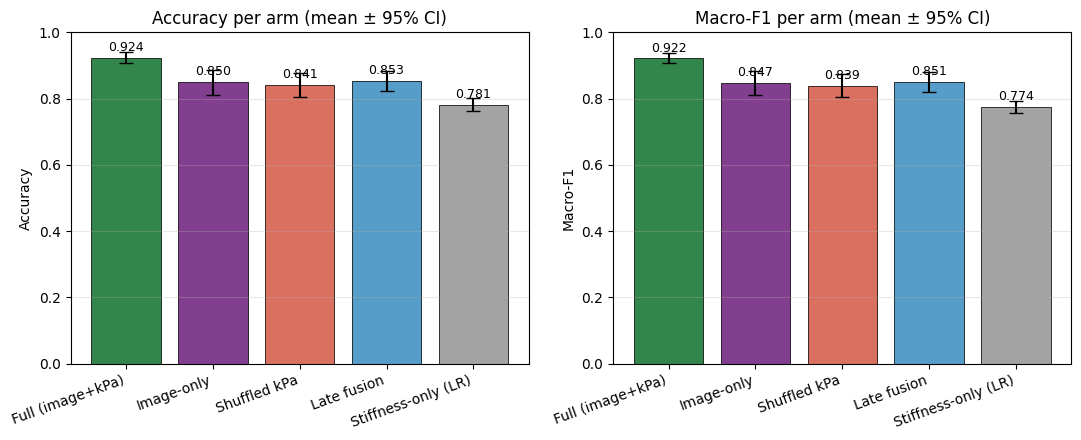

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, met, title in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    means, los, his, cols = [], [], [], []
    for arm in ARM_ORDER:
        vals = results_df[results_df["arm"] == arm][met].dropna().values
        mean, lo, hi = mean_ci(vals)
        means.append(mean)
        err = (hi - lo) / 2 if np.isfinite(hi) else 0.0
        los.append(err); his.append(err); cols.append(PALETTE[arm])
    xpos = np.arange(len(ARM_ORDER))
    ax.bar(xpos, means, yerr=los, capsize=5, color=cols, alpha=0.9, edgecolor="black", linewidth=0.6)
    ax.set_xticks(xpos)
    ax.set_xticklabels([ARM_LABELS[a] for a in ARM_ORDER], rotation=20, ha="right")
    ax.set_ylabel(title); ax.set_title(f"{title} per arm (mean ± 95% CI)")
    ax.set_ylim(0, 1.0); ax.grid(axis="y", alpha=0.3)
    for x, m_ in zip(xpos, means):
        ax.text(x, m_ + 0.02, f"{m_:.3f}", ha="center", fontsize=9)
fig.tight_layout()
savefig(fig, "fig1_headline_bars")
fig

### 10.2 Key-control panel — Full vs Shuffled kPa (the decisive comparison)

In [23]:
if "full" in ARMS and "shuffled" in ARMS:
    fig, ax = plt.subplots(figsize=(6, 5))
    mets = ["accuracy", "macro_f1", "roc_auc_ovr"]
    labels = ["Accuracy", "Macro-F1", "ROC-AUC"]
    width = 0.36
    xpos = np.arange(len(mets))
    for i, arm in enumerate(["full", "shuffled"]):
        means, errs = [], []
        for met in mets:
            vals = results_df[results_df["arm"] == arm][met].dropna().values
            mean, lo, hi = mean_ci(vals)
            means.append(mean); errs.append((hi - lo) / 2 if np.isfinite(hi) else 0)
        ax.bar(xpos + (i - 0.5) * width, means, width, yerr=errs, capsize=4,
               label=ARM_LABELS[arm], color=PALETTE[arm], edgecolor="black", linewidth=0.6)
    ax.set_xticks(xpos); ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
    ax.set_title("Key control: real pairing (Full) vs broken pairing (Shuffled)")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    savefig(fig, "fig2_key_control_full_vs_shuffled")
    fig

### 10.3 Per-seed spread — box/strip plot per metric (justifies the CIs)

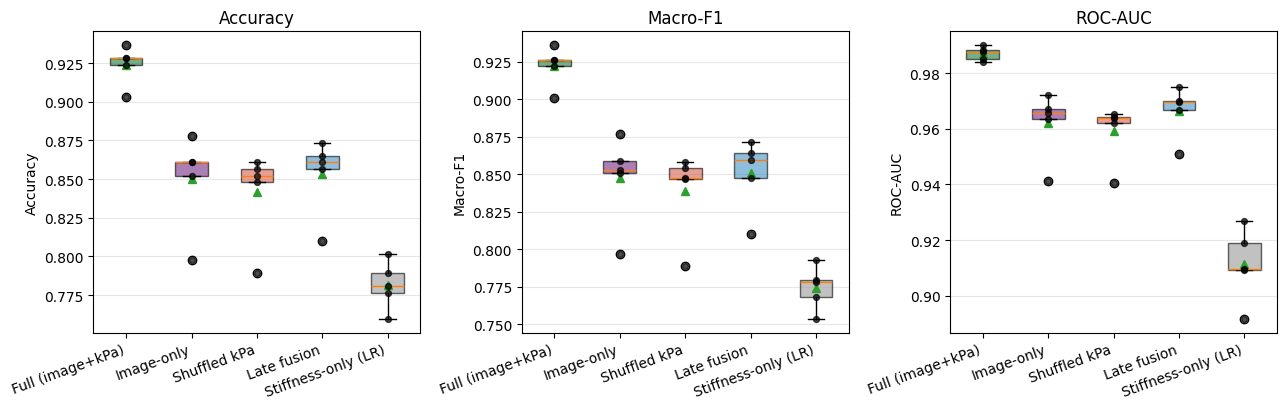

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, met, title in zip(axes, ["accuracy", "macro_f1", "roc_auc_ovr"],
                          ["Accuracy", "Macro-F1", "ROC-AUC"]):
    data = [results_df[results_df["arm"] == a][met].dropna().values for a in ARM_ORDER]
    bp = ax.boxplot(data, widths=0.5, patch_artist=True, showmeans=True)
    for patch, arm in zip(bp["boxes"], ARM_ORDER):
        patch.set_facecolor(PALETTE[arm]); patch.set_alpha(0.6)
    for i, arm in enumerate(ARM_ORDER):  # overlay individual seeds
        ys = results_df[results_df["arm"] == arm][met].dropna().values
        ax.scatter(np.full(len(ys), i + 1), ys, color="black", s=18, zorder=3, alpha=0.7)
    ax.set_xticks(np.arange(1, len(ARM_ORDER) + 1))
    ax.set_xticklabels([ARM_LABELS[a] for a in ARM_ORDER], rotation=20, ha="right")
    ax.set_ylabel(title); ax.set_title(title); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
savefig(fig, "fig3_per_seed_boxplots")
fig

### 10.4 Confusion matrices per arm (pooled over seeds)

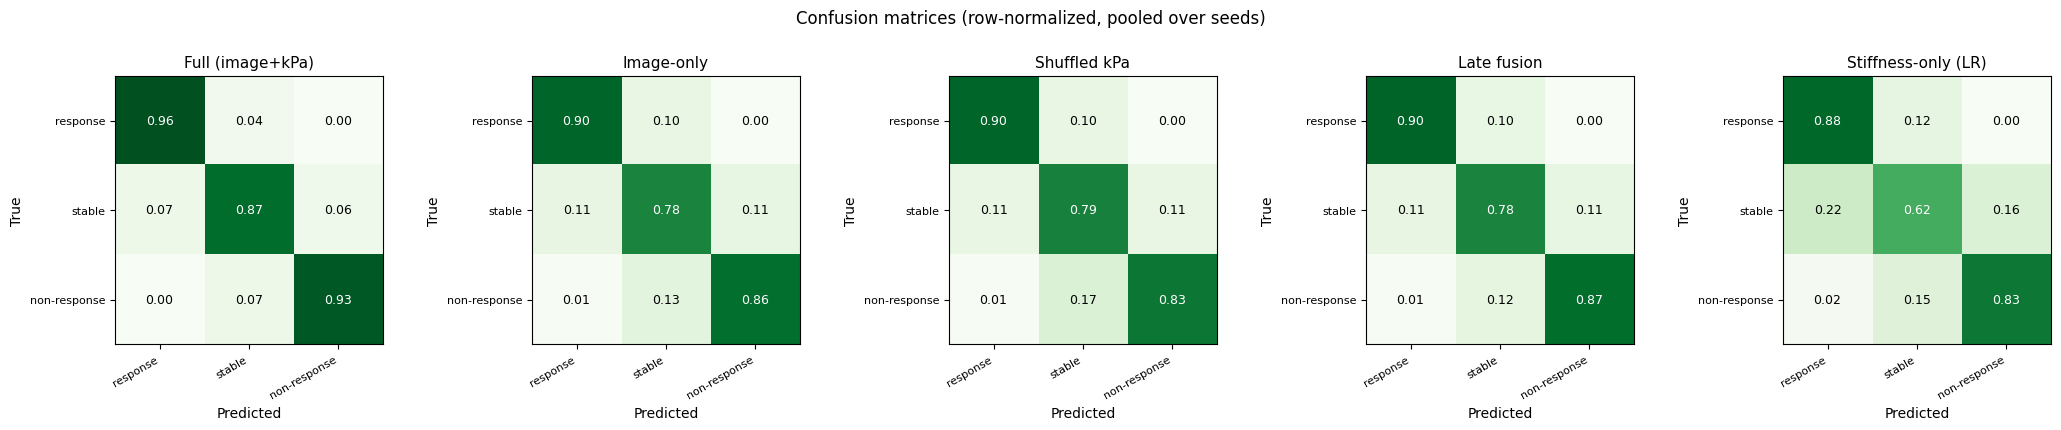

In [25]:
fig, axes = plt.subplots(1, len(ARM_ORDER), figsize=(4.2 * len(ARM_ORDER), 4))
if len(ARM_ORDER) == 1:
    axes = [axes]
for ax, arm in zip(axes, ARM_ORDER):
    yt, yp = [], []
    for seed in SEEDS:
        fp = DIR_PREDS / f"preds_{arm}_seed{seed}.csv"
        if fp.exists():
            d = pd.read_csv(fp); yt += list(d["y_true"]); yp += list(d["y_pred"])
    cm = confusion_matrix(yt, yp, labels=list(range(NUM_CLASSES)))
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cmn, cmap="Greens", vmin=0, vmax=1)
    ax.set_title(ARM_LABELS[arm], fontsize=11)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center",
                    color="white" if cmn[i, j] > 0.5 else "black", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.suptitle("Confusion matrices (row-normalized, pooled over seeds)", y=1.03)
fig.tight_layout()
savefig(fig, "fig4_confusion_matrices")
fig

### 10.5 ROC overlay — macro one-vs-rest AUC per arm (pooled predictions)

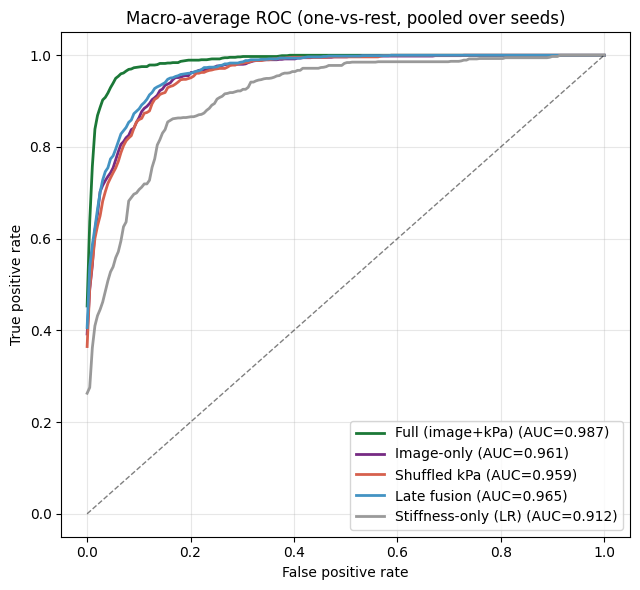

In [26]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for arm in ARM_ORDER:
    yt, probs = [], []
    for seed in SEEDS:
        fp = DIR_PREDS / f"preds_{arm}_seed{seed}.csv"
        if fp.exists():
            d = pd.read_csv(fp)
            yt += list(d["y_true"]); probs.append(d[PROB_COLS].values)
    if not probs:
        continue
    yt = np.array(yt); probs = np.vstack(probs)
    yb = label_binarize(yt, classes=list(range(NUM_CLASSES)))
    # macro-average ROC
    fprs, tprs = [], []
    grid = np.linspace(0, 1, 200); mean_tpr = np.zeros_like(grid)
    for c in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(yb[:, c], probs[:, c])
        mean_tpr += np.interp(grid, fpr, tpr)
    mean_tpr /= NUM_CLASSES
    macro_auc = auc(grid, mean_tpr)
    ax.plot(grid, mean_tpr, color=PALETTE[arm], lw=2,
            label=f"{ARM_LABELS[arm]} (AUC={macro_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Macro-average ROC (one-vs-rest, pooled over seeds)")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, "fig5_roc_overlay")
fig

### 10.6 Calibration / reliability curves per arm (Reviewer #4)

           arm    ECE
          full 0.0106
    image_only 0.0179
      shuffled 0.0222
   late_fusion 0.0191
stiffness_only 0.0768


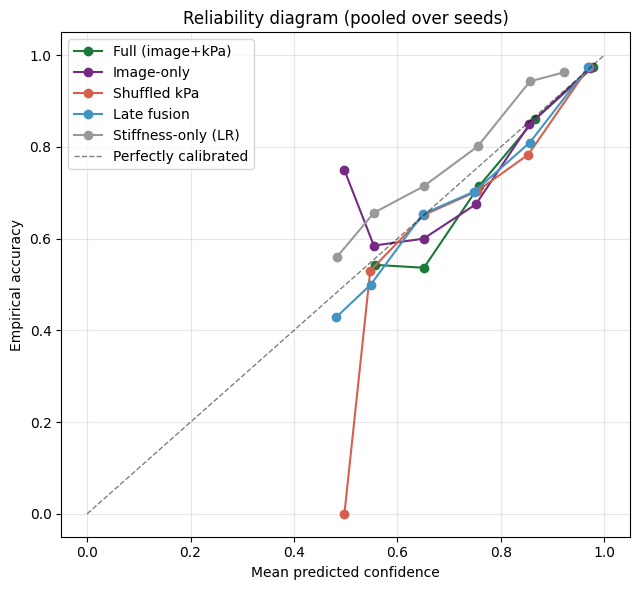

In [27]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ece_rows = []
for arm in ARM_ORDER:
    yt, probs = [], []
    for seed in SEEDS:
        fp = DIR_PREDS / f"preds_{arm}_seed{seed}.csv"
        if fp.exists():
            d = pd.read_csv(fp)
            yt += list(d["y_true"]); probs.append(d[PROB_COLS].values)
    if not probs:
        continue
    yt = np.array(yt); probs = np.vstack(probs)
    conf = probs.max(axis=1); pred = probs.argmax(axis=1); correct = (pred == yt).astype(float)
    # reliability curve (confidence vs accuracy)
    frac_pos, mean_pred = calibration_curve(correct, conf, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, marker="o", color=PALETTE[arm], label=ARM_LABELS[arm])
    # Expected Calibration Error
    bins = np.linspace(0, 1, 11); ece = 0.0
    for b in range(10):
        m = (conf > bins[b]) & (conf <= bins[b + 1])
        if m.sum() > 0:
            ece += (m.sum() / len(conf)) * abs(correct[m].mean() - conf[m].mean())
    ece_rows.append({"arm": arm, "ECE": round(float(ece), 4)})
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfectly calibrated")
ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
ax.set_title("Reliability diagram (pooled over seeds)")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, "fig6_calibration")
ece_df = pd.DataFrame(ece_rows)
ece_df.to_csv(DIR_TABLES / "calibration_ece.csv", index=False)
print(ece_df.to_string(index=False))
fig

### 10.7 Radar / spider chart — multi-metric overview per arm

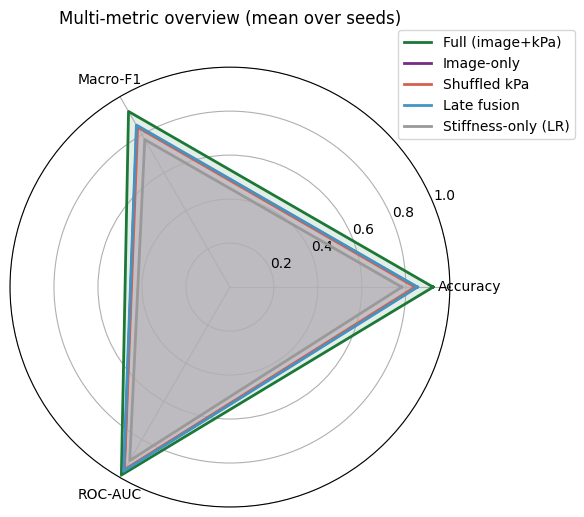

In [28]:
metrics_radar = ["accuracy", "macro_f1", "roc_auc_ovr"]
labels_radar  = ["Accuracy", "Macro-F1", "ROC-AUC"]
angles = np.linspace(0, 2 * np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for arm in ARM_ORDER:
    vals = []
    for met in metrics_radar:
        v = results_df[results_df["arm"] == arm][met].dropna().values
        vals.append(float(np.mean(v)) if len(v) else 0.0)
    vals += vals[:1]
    ax.plot(angles, vals, color=PALETTE[arm], lw=2, label=ARM_LABELS[arm])
    ax.fill(angles, vals, color=PALETTE[arm], alpha=0.12)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels_radar)
ax.set_ylim(0, 1.0)
ax.set_title("Multi-metric overview (mean over seeds)", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
fig.tight_layout()
savefig(fig, "fig7_radar")
fig

### 10.8 Training curves — val loss/accuracy per arm (convergence check)

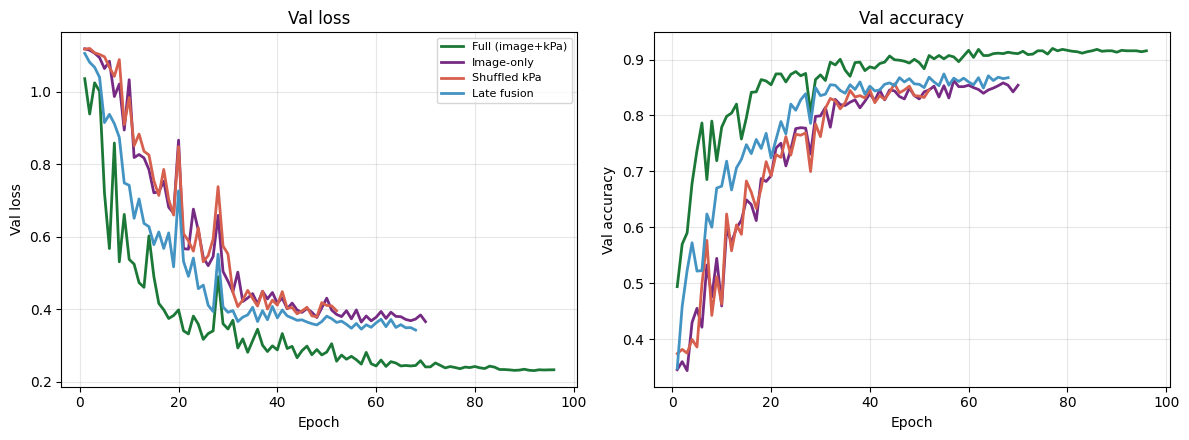

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for arm in ARM_ORDER:
    val_losses, val_accs = [], []
    for seed in SEEDS:
        fp = DIR_HIST / f"history_{arm}_seed{seed}.json"
        if fp.exists():
            h = json.load(open(fp))
            if "val_loss" in h: val_losses.append(h["val_loss"])
            if "val_accuracy" in h: val_accs.append(h["val_accuracy"])
    # plot mean curve (truncate to shortest run due to early stopping)
    for ax, series, ttl in zip(axes, [val_losses, val_accs], ["Val loss", "Val accuracy"]):
        if series:
            L = min(len(s) for s in series)
            arr = np.array([s[:L] for s in series])
            mean = arr.mean(axis=0)
            ax.plot(range(1, L + 1), mean, color=PALETTE[arm], lw=2, label=ARM_LABELS[arm])
            ax.set_xlabel("Epoch"); ax.set_ylabel(ttl); ax.set_title(ttl)
            ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.tight_layout()
savefig(fig, "fig8_training_curves")
fig

## 11. Interpreting the result (what to write in the rebuttal)

**The `shuffled` arm is trained on broken image↔kPa pairings (train+val permuted)
but evaluated on the REAL, correctly-paired test set.** So:

- **full ≫ shuffled** → a model that couldn't learn the true pairing performs far
  worse on real data → the full model's gain comes from **genuine cross-modal
  learning of the image↔kPa relationship**, not the scalar's marginal alone.
  **This is the key control.** (If full ≈ shuffled, the pairing was not being used.)
- **full > image_only** → kPa adds information beyond the image alone.
- **full > late_fusion** → token-level (early) fusion beats naive logit averaging,
  supporting the architectural claim. (Branch capacity and l2 are matched, so the
  difference is attributable to fusion *timing*, not capacity.)
- **full > stiffness_only** → the multimodal model clears the scalar's own ceiling;
  the kPa baseline is included as a matched 5th arm (same splits/seeds), so this is a
  fair, like-for-like comparison.

**Disclosure for the methods/rebuttal:** ablation arms use geometric augmentation
only (color augmentation disabled) so that all arms share identical preprocessing;
absolute accuracy therefore differs slightly from the primary reported model, but
relative comparisons between arms are controlled. All numbers are mean ± 95% CI over
the seeds, with paired t-tests (Holm–Bonferroni corrected) for model-vs-model
comparisons. GPU op-determinism is enabled best-effort; per-seed runs are not
guaranteed bit-identical, which is expected and is why CIs are reported over seeds.


## 12. Output manifest & how to file results locally

After the run, download `./ablation_results/` from RunPod. Its layout mirrors the
project, so it files cleanly:

```
ablation_results/
├── tables/          → 05_results/MM-ViT16/ablations/tables/
│   ├── ablation_runs.csv                 (raw per arm×seed metrics)
│   ├── ablation_summary_mean_ci.csv      (★ main rebuttal table)
│   ├── ablation_summary_pretty.csv
│   ├── ablation_statistical_comparison.csv
│   └── calibration_ece.csv
├── predictions/     → 05_results/MM-ViT16/ablations/predictions/   (per-image test preds)
├── histories/       → 05_results/MM-ViT16/ablations/histories/     (training curves)
├── figures/pdf|png  → 05_results/MM-ViT16/ablations/figures/       (8 figures)
├── config/          → 05_results/MM-ViT16/ablations/config/        (run_config + split manifests)
└── models/          → 03_models/MM-ViT16/ablations/                (20 trained .keras)
```

Suggested local filing (run from project root after download):
```bash
mkdir -p 05_results/MM-ViT16/ablations 03_models/MM-ViT16/ablations
rsync -a ablation_results/{tables,predictions,histories,figures,config} 05_results/MM-ViT16/ablations/
rsync -a ablation_results/models/ 03_models/MM-ViT16/ablations/
```


In [30]:
# Final manifest: list everything produced, with sizes.
import os
print("OUTPUT MANIFEST —", OUTPUT_DIR.resolve(), "\n")
total = 0
for root, _, files in os.walk(OUTPUT_DIR):
    for fn in sorted(files):
        p = Path(root) / fn
        sz = p.stat().st_size; total += sz
        print(f"  {sz/1024:8.1f} KB  {p.relative_to(OUTPUT_DIR)}")
print(f"\nTotal: {total/1024/1024:.1f} MB across {sum(len(f) for _,_,f in os.walk(OUTPUT_DIR))} files")

OUTPUT MANIFEST — /app/ablation_results 

       2.5 KB  tables/ablation_runs.csv
       0.8 KB  tables/ablation_statistical_comparison.csv
       0.7 KB  tables/ablation_summary_mean_ci.csv
       0.4 KB  tables/ablation_summary_pretty.csv
       0.1 KB  tables/calibration_ece.csv
      19.1 KB  predictions/preds_full_seed1.csv
      18.9 KB  predictions/preds_full_seed2.csv
      19.0 KB  predictions/preds_full_seed3.csv
      19.1 KB  predictions/preds_full_seed4.csv
      18.9 KB  predictions/preds_full_seed42.csv
      18.9 KB  predictions/preds_image_only_seed1.csv
      18.7 KB  predictions/preds_image_only_seed2.csv
      18.9 KB  predictions/preds_image_only_seed3.csv
      18.9 KB  predictions/preds_image_only_seed4.csv
      18.7 KB  predictions/preds_image_only_seed42.csv
      18.9 KB  predictions/preds_late_fusion_seed1.csv
      18.7 KB  predictions/preds_late_fusion_seed2.csv
      18.9 KB  predictions/preds_late_fusion_seed3.csv
      18.8 KB  predictions/preds_late_fu

In [31]:
import shutil
shutil.make_archive("ablation_results", "zip", "ablation_results")
print("Created ablation_results.zip")

Created ablation_results.zip
